# Customer Churn: Bagging vs Boosting

**Ensemble methods on a real retention problem**

A single tree model is easy to read but fragile: grown deep it **memorises** the training data and
then swings wildly on data it hasn't seen. This notebook fixes that by combining many trees into an
**ensemble**, and contrasts the two great families for doing so **bagging** and **boosting** on
a classic business problem: predicting which telecom customers will **churn** (cancel their
service).

We use the *Telco Customer Churn* dataset (7,043 customers). About **27%** churn, so accuracy alone
is misleading a model that predicts *"nobody leaves"* is already 73% accurate and worthless. As
in earlier weeks we judge everything on **F1 and recall for the "Churn" class**, measured on **both
the training and test sets** so the train/test *gap* the fingerprint of overfitting is always
in view.

**The journey:**

| Step | What we do | Why |
|---|---|---|
| **1. Explore** | Exploratory Data Analysis | Understand the data before modelling |
| **2. Preprocess** | Encode **all** features, stratified split | Do transformations as per observations in EDA |
| **3. Baseline** | A single Decision Tree | See high variance / overfitting first-hand |
| **4. Bagging** | `BaggingClassifier`, `RandomForest` | Reduce **variance** by averaging many trees |
| **5. Boosting** | `AdaBoost`, `XGBoost` | Reduce **bias** by correcting mistakes in sequence |

---

## Setup: Imports



In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

RANDOM_STATE = 42

## 1: Load & Explore the Data

The loader tries a local file first, then a public mirror, so the notebook runs anywhere.

In [ ]:
PATH = "/content/Telco-Customer-Churn.csv"

df = pd.read_csv(PATH)


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### why accuracy will mislead us?



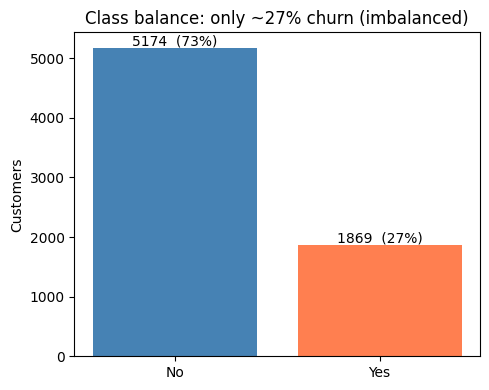

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Churn"].value_counts()

ax.bar(counts.index, counts.values, color=["steelblue", "coral"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v}  ({v/len(df):.0%})", ha="center")
ax.set_ylabel("Customers")
ax.set_title("Class balance: only ~27% churn (imbalanced)")
plt.tight_layout()
plt.show()

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

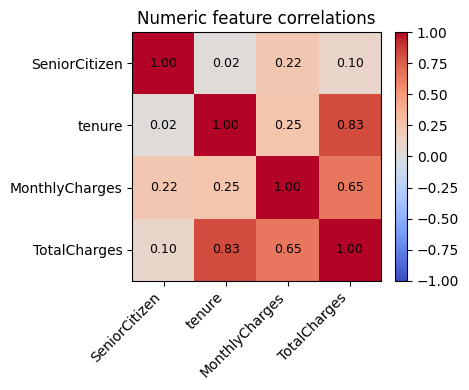

In [ ]:

num_cols = df.select_dtypes(include=['number']).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Numeric feature correlations")
plt.tight_layout()
plt.show()

## 2: Preprocessing — Keep Every Feature

A deliberate choice here: **we do not hand-pick or randomly drop predictive features.** The only
column we remove is **`customerID`**, and that is not feature selection — it is a unique identifier
(7,043 distinct values, one per row) with zero predictive content that would only invite the model
to memorise rows.

Everything else stays. We
fit scikit-learn's **`OneHotEncoder`** on the **training data only** and apply that same mapping to
the test set. Setting **`handle_unknown="ignore"`** means any category that shows up only in
the test set is safely encoded as all-zeros instead of crashing. No categories are dropped, so
every piece of information reaches the trees, and since trees don't need feature scaling we skip it.
We split with **`stratify=y`** so the ~27% churn rate is preserved in both train and test.

In [ ]:
y = (df["Churn"] == "Yes").astype(int)

# Remove the target column and customer ID from the features
X = df.drop(columns=["Churn", "customerID"])

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,                 # Keep the same class distribution
    random_state=RANDOM_STATE
)

In [ ]:
# Numerical columns
numeric_columns = (
    X_train_raw
    .select_dtypes(include="number")
    .columns
    .tolist()
)

# Everything else is categorical
categorical_columns = (
    X_train_raw
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)


In [ ]:
encoder = OneHotEncoder(
    handle_unknown="ignore",    # Ignore categories seen only in the test set
    sparse_output=False          # Return a NumPy array instead of a sparse matrix
)


# Learn the categories from training data
encoder.fit(X_train_raw[categorical_columns])




def encode_features(data):

    # Convert categorical columns into one-hot encoded columns
    encoded_array = encoder.transform(
        data[categorical_columns]
    )

    # Convert NumPy array to DataFrame
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_columns),
        index=data.index
    )

    # Keep the numerical columns
    numeric_df = data[numeric_columns]

    # Combine numerical and encoded categorical columns
    final_df = pd.concat(
        [numeric_df, encoded_df],
        axis=1
    )

    return final_df



X_train = encode_features(X_train_raw)
X_test = encode_features(X_test_raw)


feature_names = X_train.columns

print(f"Total features after encoding : {X_train.shape[1]}")

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

print(f"Training churn rate : {y_train.mean():.3f}")
print(f"Testing churn rate  : {y_test.mean():.3f}")

Total features after encoding : 45
Training samples : 5634
Testing samples  : 1409
Training churn rate : 0.265
Testing churn rate  : 0.265


### Evaluation Helper

This helper does one job:
print the "Churn" class metrics for **train and test side by side** (so the overfitting gap is
obvious).

In [ ]:
results = {}   # filled as we go

def evaluate(name, model):
    """Print train vs test metrics for the 'Churn' class and store the scores.
    The model must already be fitted (we fit it in its own cell)."""
    yhat_tr, yhat_te = model.predict(X_train), model.predict(X_test)

    def block(yt, yp):
        return (accuracy_score(yt, yp), precision_score(yt, yp),
                recall_score(yt, yp), f1_score(yt, yp,))

    tr, te = block(y_train, yhat_tr), block(y_test, yhat_te)

    print(f"  {name}")
    print(f"  {'metric':<12}{'train':>8}{'test':>8}")
    for lbl, i in [("Accuracy", 0), ("Precision", 1), ("Recall", 2), ("F1 (Churn)", 3)]:
        print(f"  {lbl:<12}{tr[i]:>8.3f}{te[i]:>8.3f}")
    print(f"  {'F1 gap':<12}{'':>8}{tr[3] - te[3]:>8.3f}")

    results[name] = {"model": model, "y_pred_test": yhat_te,
                     "train_f1": tr[3], "test_f1": te[3],
                     "train_acc": tr[0], "test_acc": te[0], "test_recall": te[2]}
    return model

### First, a picture: what is *Gini impurity*?

A decision tree splits customers into groups and wants each group to be as **"pure"** as possible,
ideally all churn or all stay. *Gini impurity* is simply a score for **how mixed a group is.**

**The intuition.** Picture each group as a bag of marbles: 🔵 = a customer who *stays*, 🔴 = a
customer who *churns*. Reach in, grab one at random, and guess its label according to the bag's mix.
Gini impurity is **how often that guess is wrong**:

A bag that is **all one colour** → you're never surprised → **Gini = 0** (perfectly pure).

A **50 / 50** bag → you're wrong as often as right → **Gini = 0.5** (the worst case for two classes).

<div align="center">

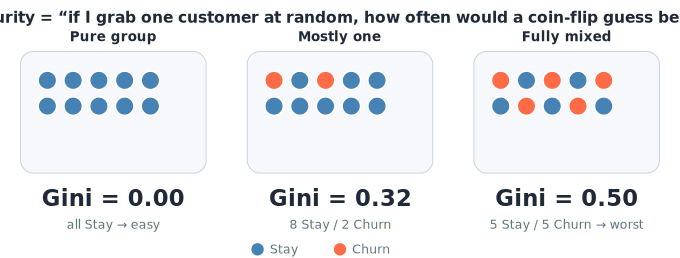

</div>


Formally, for classes with proportions $p_i$: $\;\text{Gini} = 1 - \sum_i p_i^2$. A split is
**good** when its child groups have *lower* Gini than the parent i.e. it sorts churners away from
stayers. At every node the tree tries each feature and threshold and keeps the split that drops
impurity the most.

## 3: Baseline — Decision Tree

**How it works.** A decision tree splits the data one feature at a time. At each node it searches
every feature for the split that best separates churners from stayers (measured by *Gini impurity*
or entropy), then repeats on each side. Left unconstrained, it keeps splitting until the leaves are
almost pure.

**Why it overfits.** That box drawing means the tree fits the training set almost perfectly, but
its structure lurches whenever the data shifts a little. This sensitivity is **high variance**, and
it is exactly what produces a near perfect train score sitting next to a poor test score.

In [ ]:
dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
evaluate("Decision Tree (unconstrained)", dt)

  Decision Tree (unconstrained)
  metric         train    test
  Accuracy       0.998   0.732
  Precision      0.993   0.495
  Recall         0.999   0.489
  F1 (Churn)     0.996   0.492
  F1 gap                 0.504


DecisionTreeClassifier(class_weight='balanced', random_state=42)

## Why `class_weight="balanced"`?

Look at the **"Mostly one"** group above: 8 Stay, 2 Churn, Gini = 0.32.

A tree trained on data like this has an easy shortcut just keep predicting
**Stay** and it's right 80% of the time. The 2 Churn customers barely move the
impurity, so the tree has little incentive to work hard to separate them. But
those churners are usually the whole reason we built the model.

`class_weight="balanced"` fixes this by making the **rare class count for more**.

### What it actually computes

sklearn sets each class weight inversely proportional to how often it appears:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_c}$$

For our 8-Stay / 2-Churn node (10 samples, 2 classes):

| Class | Count | Weight $w_c$ | Effective count |
|-------|-------|--------------|-----------------|
| Stay  | 8     | 10 / (2×8) = **0.625** | 8 × 0.625 = **5** |
| Churn | 2     | 10 / (2×2) = **2.50**  | 2 × 2.50 = **5** |

Each Churn example now carries **4× the weight** of a Stay example.

### The connection to Gini

The tree computes impurity from these *weighted* counts, not the raw ones.
So after balancing, the node effectively looks like **5 Stay / 5 Churn**:

$$\text{Gini} = 1 - (0.5^2 + 0.5^2) = 0.50$$

In other words, `class_weight="balanced"` turns the **"Mostly one"** panel
(Gini 0.32) into the **"Fully mixed"** panel (Gini 0.50) *in the tree's eyes*.
The minority class is no longer easy to ignore, so the model is pushed to find
splits that genuinely isolate churners trading a little overall accuracy for
much better **recall on the class we care about**.

To *see* what a tree does, here are the top few levels of a shallow tree (full depth would be
unreadable). Each box is a yes/no question; colour shows which class dominates the customers that
land there.

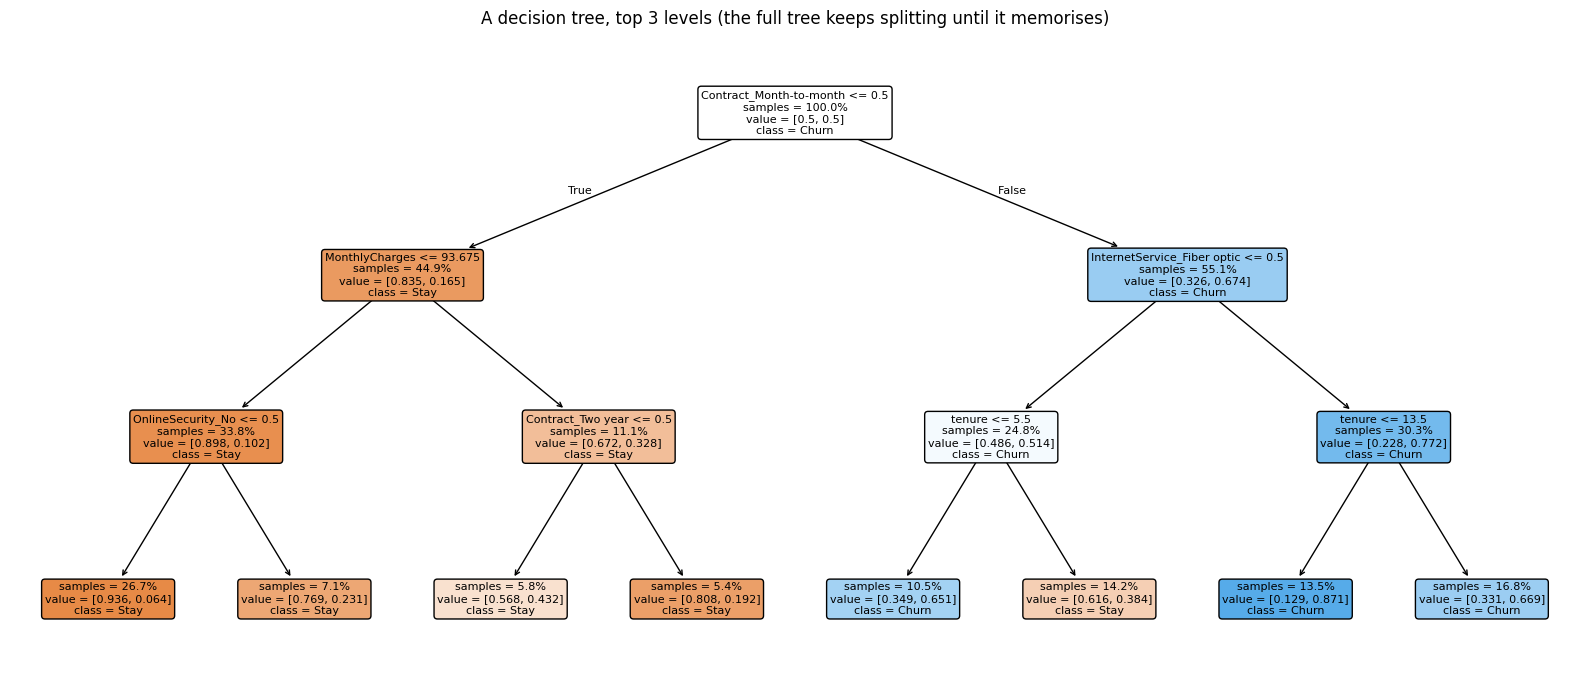

In [ ]:
demo_tree = DecisionTreeClassifier(class_weight="balanced", max_depth = 3, random_state=RANDOM_STATE).fit(X_train, y_train)
plt.figure(figsize=(16, 7))
plot_tree(demo_tree, feature_names=feature_names, class_names=["Stay", "Churn"],
          filled=True, rounded=True, fontsize=8, impurity=False, proportion=True)
plt.title("A decision tree, top 3 levels (the full tree keeps splitting until it memorises)")
plt.tight_layout()
plt.show()

## 4: Bagging — Averaging Away the Variance

**How it works.** *Bagging* (Bootstrap Aggregating) draws many bootstrap samples new training
sets of the same size, sampled **with replacement** fits an independent tree on each, and
**averages their votes**. Each tree still overfits its own sample, but their mistakes are only
partly correlated, so averaging cancels much of the noise.

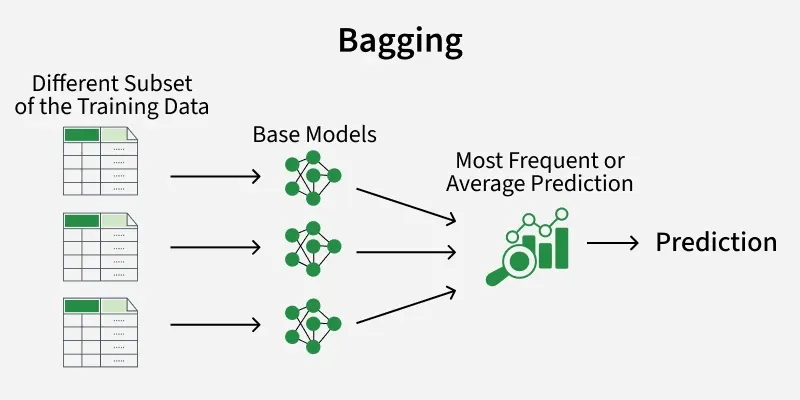




For our **classification** task, "averaging" means a **majority vote**: each tree predicts *Churn*
or *Stay* for a customer, and the ensemble goes with the class most trees chose.



In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(min_samples_split=10, class_weight="balanced", random_state=RANDOM_STATE),
    n_estimators=200,
    max_samples=0.7,
    bootstrap=True,
    random_state=RANDOM_STATE,
)
bag.fit(X_train, y_train)
evaluate("Bagging (200 trees)", bag)

  Bagging (200 trees)
  metric         train    test
  Accuracy       0.920   0.781
  Precision      0.826   0.582
  Recall         0.886   0.618
  F1 (Churn)     0.855   0.599
  F1 gap                 0.256


BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   min_samples_split=10,
                                                   random_state=42),
                  max_samples=0.7, n_estimators=200, random_state=42)

### Random Forest — bagging with decorrelated trees

**How it works.** A *Random Forest* is bagging plus one extra idea: at **each split**, a tree may
only consider a **random subset of the features** (often about $\sqrt{p}$ of them). This stops
every tree from leaning on the same one or two dominant predictors here, contract type and tenure so the trees **disagree more**. More independent errors means a steadier average, which is why
Random Forest is usually the strongest member of the bagging family.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    min_samples_split=10,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf)

  Random Forest
  metric         train    test
  Accuracy       0.891   0.777
  Precision      0.746   0.568
  Recall         0.896   0.666
  F1 (Churn)     0.814   0.613
  F1 gap                 0.201


RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=200, random_state=42)

## 5: Boosting — Fixing Mistakes in Sequence

Bagging builds trees **in parallel** and averages them. **Boosting** builds them **one after
another**, each new tree focusing on the customers the current ensemble got wrong. Instead of
reducing variance, boosting chips away at **bias** — the systematic errors a weak model makes — and
often lands the best test scores, at the cost of more sensitivity to its settings (run too many
rounds and it will overfit too).

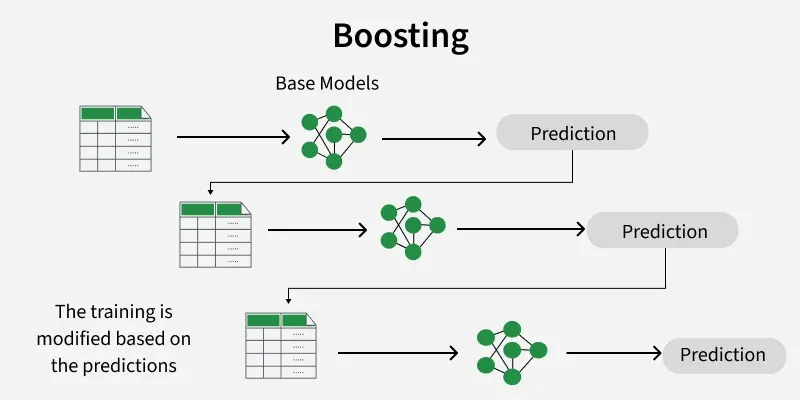

### AdaBoost

**How it works.** AdaBoost trains a sequence of *weak learners* usually depth 1 "stumps." After
each stump it **increases the weight of the misclassified customers** so the next stump pays them
more attention, then combines all the stumps in a **weighted vote** where more accurate stumps
count for more. For **classification** the final label is the sign of that weighted vote: whichever
of *Churn* / *Stay* the confident stumps lean toward.

**AdaBoost vs. Random Forest : same building block, opposite philosophy.** Both are ensembles of
decision trees, yet they combine them in opposite ways. **Random Forest** (bagging) grows many
*full depth* trees **in parallel**, each on a random bootstrap sample and a random subset of
features, then lets them vote **equally**; its job is to cut **variance**, so it mainly rescues a
model that is *overfitting*. **AdaBoost** (boosting) grows *shallow stumps* **one after another**,
each trained on data that has been **re weighted** to emphasise the customers the previous stumps
misclassified, then combines them in a **weighted** vote where more accurate stumps count for more;
its job is to cut **bias**, so it mainly rescues a model that is *underfitting*. In one line:
Random Forest reduces variance by averaging independent *strong* trees; AdaBoost reduces bias by
sequentially correcting *weak* ones.



In [ ]:
dt_weak = DecisionTreeClassifier(max_depth = 1, random_state=RANDOM_STATE)
dt_weak.fit(X_train, y_train)
evaluate("Decision Tree (stump)", dt_weak)

  Decision Tree (stump)
  metric         train    test
  Accuracy       0.735   0.735
  Precision      0.000   0.000
  Recall         0.000   0.000
  F1 (Churn)     0.000   0.000
  F1 gap                 0.000


DecisionTreeClassifier(max_depth=1, random_state=42)

In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=RANDOM_STATE,
)
ada.fit(X_train, y_train)
evaluate("AdaBoost", ada)

  AdaBoost
  metric         train    test
  Accuracy       0.807   0.801
  Precision      0.665   0.650
  Recall         0.551   0.540
  F1 (Churn)     0.602   0.590
  F1 gap                 0.013


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

### XGBoost

**How it works**. XGBoost is an improved version of gradient boosting that is designed to be faster and more accurate. Like gradient boosting, it builds trees one after another, with each new tree trying to correct the mistakes made by the previous trees. It also includes features that help reduce overfitting and provides scale_pos_weight to give more importance to the minority class (for example, customers who churn). These improvements make XGBoost one of the most popular algorithms for structured (tabular) data.

**XGBoost vs. AdaBoost**. Both are boosting algorithms, but they learn in different ways. AdaBoost increases the importance of misclassified training examples so that the next tree focuses more on them. XGBoost instead trains each new tree to predict the errors made by the current model. AdaBoost usually uses very simple trees (decision stumps), whereas XGBoost typically uses slightly deeper trees that can learn more complex patterns. XGBoost also includes built-in techniques to reduce overfitting and handles imbalanced datasets using scale_pos_weight. As a result, it often achieves higher accuracy than AdaBoost on real-world datasets.



In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # weight the rare 'Churn' class

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
)

xgb.fit(X_train, y_train)
evaluate("XGBoost", xgb)


  XGBoost
  metric         train    test
  Accuracy       0.794   0.751
  Precision      0.574   0.520
  Recall         0.863   0.789
  F1 (Churn)     0.690   0.627
  F1 gap                 0.063


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## Summary

A single unconstrained tree **memorised** the training data near perfect train F1, weak test F1
because of its **high variance**. The two ensemble families cure that differently:

- **Bagging** (Bagging, Random Forest) trains many trees **in parallel** on bootstrap samples and
  **averages** them. This attacks **variance**: train F1 drops off its ceiling, test F1 rises, and
  the train/test gap collapses. Random Forest decorrelates the trees further with random feature
  subsets.
- **Boosting** (AdaBoost, XGBoost)
  trains trees **in sequence**, each fixing the last one's mistakes. This mainly reduces **bias**.

| Family | Builds trees… | Mainly reduces… | Watch out for |
|---|---|---|---|
| Bagging | in parallel, then averages | **variance** | won't fix a biased weak learner |
| Boosting | in sequence, correcting errors | **bias** | can overfit if over-trained |



---

# Revision: Support Vector Machines (SVM)

A **Support Vector Machine** separates the two classes with a boundary, but not just any boundary.
Among all the lines that split churners from stayers, it chooses the one with the **widest empty gap**
on either side imagine paving the **widest possible street** down the middle of the two groups. The
centre line of that street is the **decision boundary**; the kerbs on each side are the **margins**.


## Why SVM?

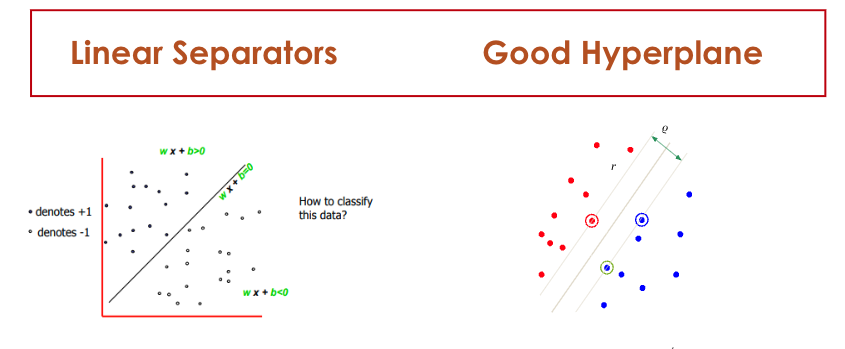

## What are support vectors and what is the objective?





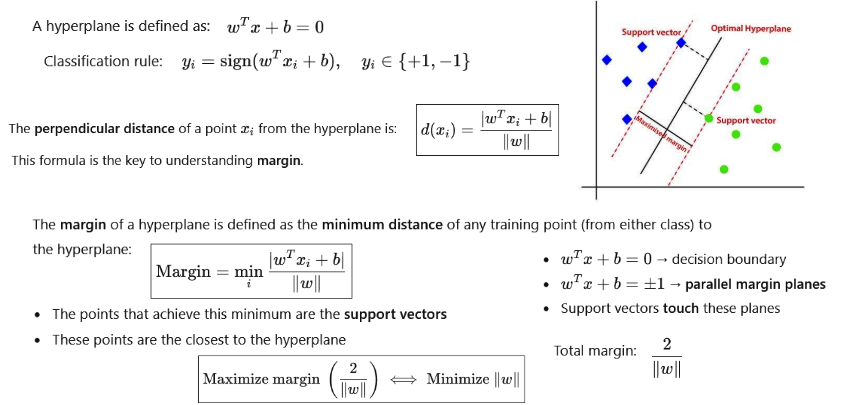




## What SVMs need that trees didn't: scaling

The score $\mathbf{w}^\top x$ adds the features together, so a feature measured in **thousands**
(`TotalCharges`) would swamp one measured in **tens** (`tenure`) purely because of its units, the SVM
would end up "listening" almost entirely to the large-scale column. The fix is to **standardise** each
numeric feature to mean $0$ and standard deviation $1$.


In [ ]:
# Scale ONLY the numeric columns (the one-hot columns are already 0/1).
scaler = StandardScaler()
X_train_svm = X_train.copy()
X_test_svm  = X_test.copy()

# Fit on train, then apply the SAME transform to test.
X_train_svm[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_svm[numeric_columns]  = scaler.transform(X_test[numeric_columns])



In [ ]:
def evaluate_svm(name, model):
    yhat_tr, yhat_te = model.predict(X_train_svm), model.predict(X_test_svm)

    def block(yt, yp):
        return (accuracy_score(yt, yp), precision_score(yt, yp),
                recall_score(yt, yp), f1_score(yt, yp))

    tr, te = block(y_train, yhat_tr), block(y_test, yhat_te)
    print(f"  {name}")
    print(f"  {'metric':<12}{'train':>8}{'test':>8}")
    for lbl, i in [("Accuracy", 0), ("Precision", 1), ("Recall", 2), ("F1 (Churn)", 3)]:
        print(f"  {lbl:<12}{tr[i]:>8.3f}{te[i]:>8.3f}")
    print(f"  {'F1 gap':<12}{'':>8}{tr[3] - te[3]:>8.3f}")

## Hard margin, soft margin, and the hinge loss

**Hard margin.** If the classes can be split by a straight line, we can insist that *every* point sit
on the correct side, past its margin:

$$ y_i(\mathbf{w}^\top x_i + b) \;\ge\; 1 \qquad \text{for every customer } i. $$

Maximising the margin then means: minimise $\tfrac{1}{2}\lVert \mathbf{w}\rVert^2$ subject to those
constraints. This is a **hard** margin (zero tolerance), no point may enter the street.

**Soft margin.** Real data overlaps, so a perfect separating line usually doesn't exist. We relax the
rule by giving each point a **slack** $\xi_i \ge 0$, how far it is allowed to fall short of its margin:

$$ y_i(\mathbf{w}^\top x_i + b) \;\ge\; 1 - \xi_i, \qquad \xi_i \ge 0, $$

and we minimise $\tfrac{1}{2}\lVert \mathbf{w}\rVert^2 + C\sum_i \xi_i$.

**The hinge loss.** That slack has a name. The penalty a single point pays is the **hinge loss**

$$ \ell\big(y, f(x)\big) \;=\; \max\!\big(0,\; 1 - y\,f(x)\big), $$

which is exactly the slack $\xi_i$: **zero** when the point is correct and beyond its margin, and
growing **linearly** the further it strays onto the wrong side. Putting it together, a soft-margin SVM
simply minimises

$$ \min_{\mathbf{w},\,b}\; \tfrac{1}{2}\lVert \mathbf{w}\rVert^{2}
\;+\; C \sum_i \max\!\big(0,\; 1 - y_i\,f(x_i)\big). $$


**`C` is the trade-off knob.** A **large** `C` makes slack expensive, so the model tolerates almost no
violations → a **hard**, narrow margin. A **small** `C` makes slack cheap, buying a **wider**, steadier
margin in exchange for a few violations. In other words `C` is a **regularisation** dial: turn it up and
the model tries to fit every training point; ease it down and it keeps the boundary simple.

The plots below shows the margin with and without slack: on the left (separable data) every
point satisfies $y_i(\mathbf{w}^\top x_i + b)\ge 1$, so all $\xi_i = 0$; on the right (overlapping data)
a few points need slack $\xi_i > 0$.



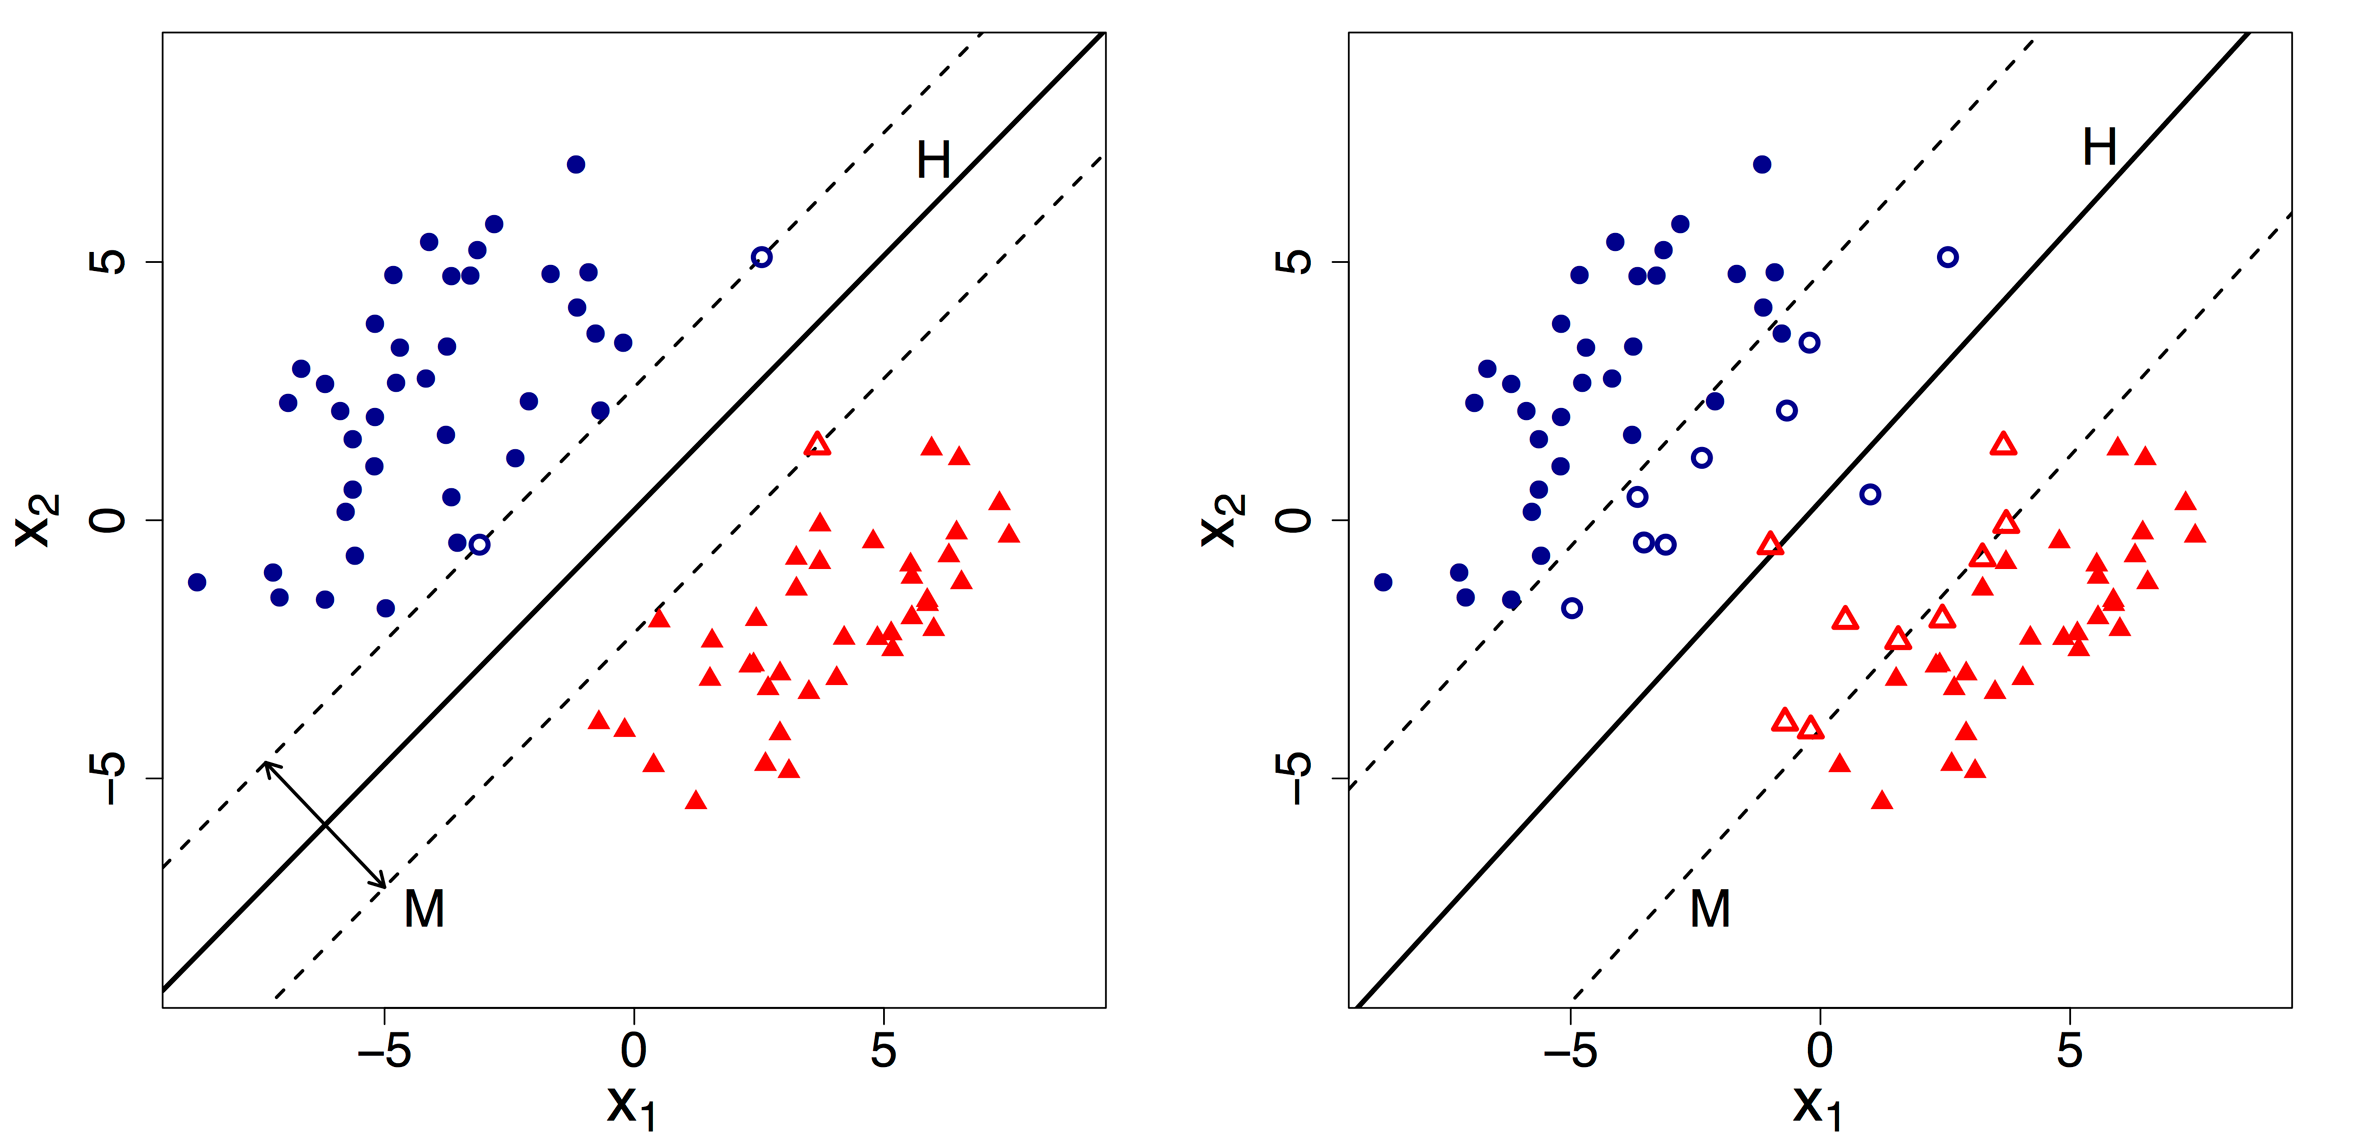

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.svm import SVC


In [ ]:
# Hard Margin SVM - Linear Kernel
svm_hard_linear = LinearSVC(
    C=1000,
    loss = 'hinge',
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter = 20000
)

svm_hard_linear.fit(X_train_svm, y_train)
evaluate_svm("Hard SVM (Linear Kernel)", svm_hard_linear)

  Hard SVM (Linear Kernel)
  metric         train    test
  Accuracy       0.619   0.617
  Precision      0.404   0.402
  Recall         0.924   0.914
  F1 (Churn)     0.562   0.559
  F1 gap                 0.004


## What is Kernel ***Trick*** and why do we need it?

Many real-world datasets are not linearly separable in the original input space:


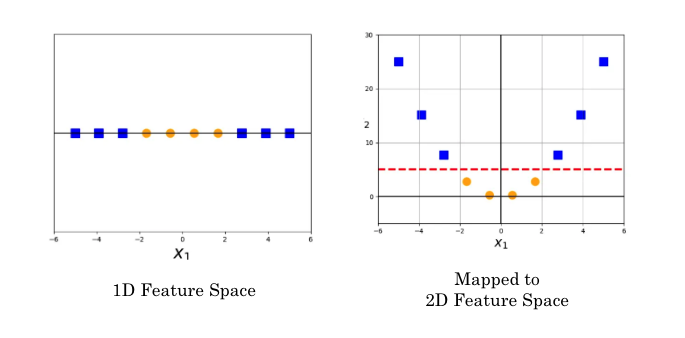


### Common Kernel Functions

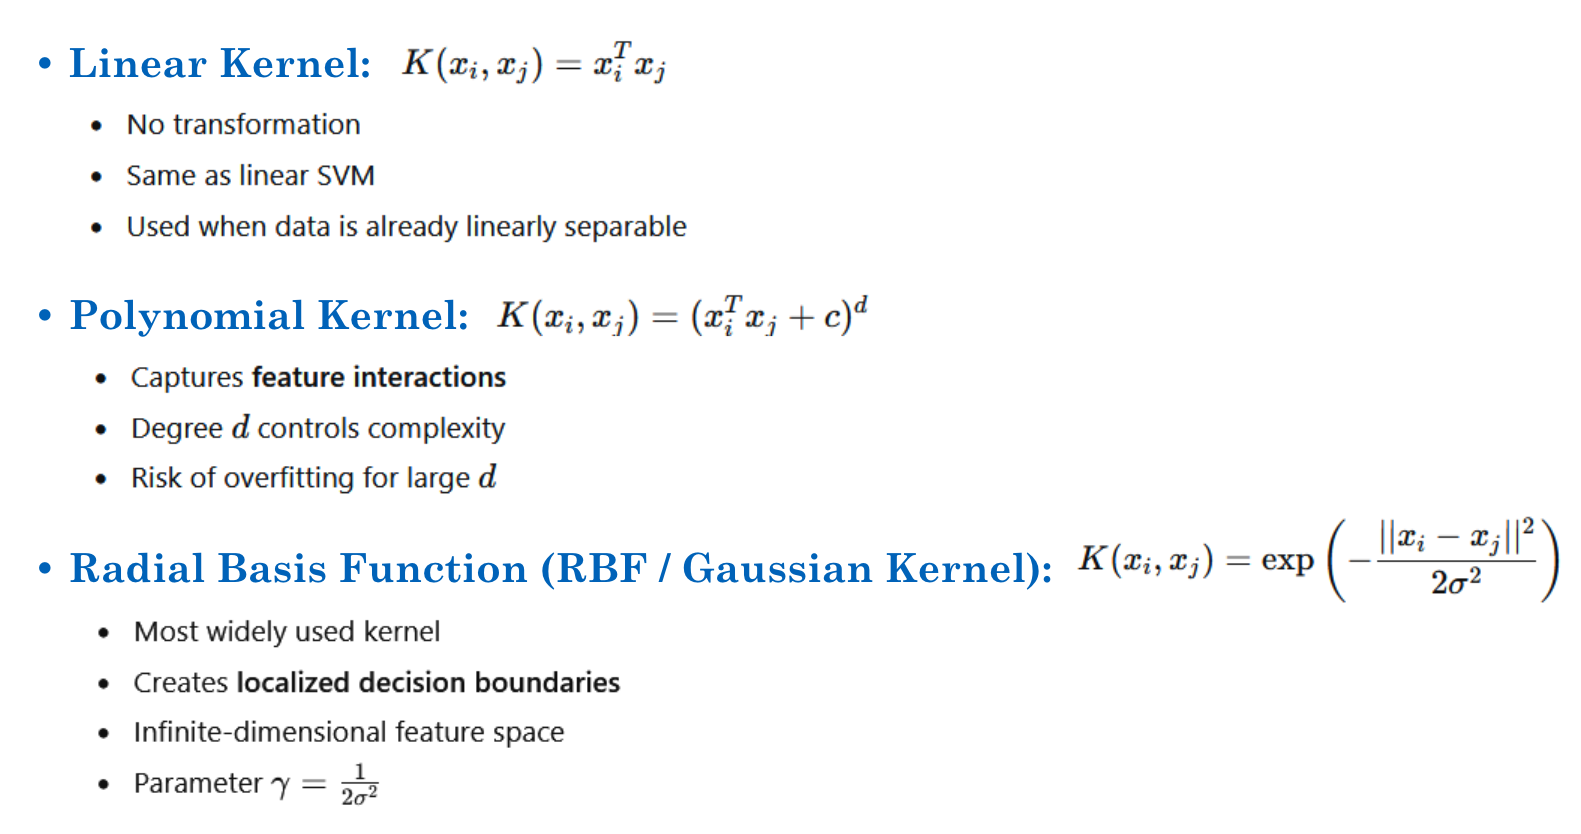

Gamma determines how quickly the similarity between two points decreases with distance.
- ** Small Gamma ** : Higher Bias, Lower Variance
- **Large Gamma ** :  Lower Bias, Higher Variance


In [ ]:
# Hard Margin SVM - Gaussian Kernel
svm_hard_rbf = SVC(
    kernel="rbf",
    C=1000,
    gamma="scale",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter = 20000

)

svm_hard_rbf.fit(X_train_svm, y_train)
evaluate_svm("Hard SVM (Gaussian Kernel)", svm_hard_rbf)

  Hard SVM (Gaussian Kernel)
  metric         train    test
  Accuracy       0.942   0.731
  Precision      0.834   0.494
  Recall         0.974   0.572
  F1 (Churn)     0.898   0.530
  F1 gap                 0.368


In [ ]:
# Soft Margin SVM - Linear Kernel
svm_soft_linear = LinearSVC(
    C=1,
    loss = 'hinge',
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter = 20000
)

svm_soft_linear.fit(X_train_svm, y_train)
evaluate_svm("Soft SVM (Linear Kernel)", svm_soft_linear)

  Soft SVM (Linear Kernel)
  metric         train    test
  Accuracy       0.702   0.694
  Precision      0.466   0.458
  Recall         0.835   0.821
  F1 (Churn)     0.598   0.588
  F1 gap                 0.011


In [ ]:
# Soft Margin SVM - Gaussian Kernel

svm_soft_rbf = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter = 20000
)

svm_soft_rbf.fit(X_train_svm, y_train)
evaluate_svm("Soft SVM (Gaussian Kernel)", svm_soft_rbf)

  Soft SVM (Gaussian Kernel)
  metric         train    test
  Accuracy       0.772   0.744
  Precision      0.547   0.512
  Recall         0.823   0.773
  F1 (Churn)     0.657   0.616
  F1 gap                 0.042


## Summary

| Setting | Train F1 | Test F1 | Train test F1 gap |
|---|---|---|---|
| **Hard margin** (`C = 1000`) - Linear Kernel    | 0.56 | 0.60 | 0.02 |
| **Hard margin** (`C = 1000`) - Gaussian Kernel   | 0.90 | 0.53 | 0.37 |
| **Soft margin** (`C = 1`) - Linear Kernel   | 0.60 | 0.59 | 0.01 |
| **Soft margin** (`C = 1`) - Gaussian Kernel  | 0.66 | 0.62 | 0.04 |
